# Model Comparison — words-asl

Side-by-side evaluation of the four trained models we kept after the cleanup.

| ID | Track | Modality | Dataset | Train classes | Eval classes |
|----|-------|----------|---------|---------------|--------------|
| `track1-wlasl100-s0`        | Track 1 | Landmark (full 33-kp) | WLASL-100   | 100 | 100 |
| `track1-wlasl9idle-s0`      | Track 1 | Landmark (full 33-kp) | WLASL-9idle | 9 (8 signs + idle) | **7** (yes/before soft-removed) |
| `track1-wlasl9idle_v2-s0`   | Track 1 | Landmark (pruned 48-kp subset) | WLASL-9idle | 9 | **7** (yes/before soft-removed) |
| `track2-wlasl9_baseline-s0` | Track 2 | Video (ViT-S/16 + temporal Tx) | WLASL-9 | 8 sign classes | **6** (yes/before soft-removed) |

> **Soft removal** (Section 4): `yes` and `before` had F1 = 0 on test (1 and 3 clips respectively — supports too small to be useful signal). At eval time we mask their logits and filter test samples whose true label is one of them. Training data + checkpoints stay untouched.

Run from `words-asl/` working dir. Heavy cells (test-set eval) are clearly marked.

## Setup

In [1]:
import json
import re
import sys
from collections import defaultdict
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'train.py').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'train.py').exists(), f'could not find words-asl root from {Path.cwd()}'
sys.path.insert(0, str(REPO_ROOT))
print('repo root:', REPO_ROOT)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

MODELS = [
    {
        'id': 'track1-wlasl100-s0',
        'short': 'T1·WLASL100',
        'track': 'Track 1',
        'modality': 'Landmark',
        'dataset': 'wlasl100',
        'config': 'configs/track1_landmark.yaml',
        'checkpoint': 'checkpoints/track1-wlasl100-s0/best.pt',
        'log': 'checkpoints/track1_train.log',
    },
    {
        'id': 'track1-wlasl9idle-s0',
        'short': 'T1·9idle',
        'track': 'Track 1',
        'modality': 'Landmark',
        'dataset': 'wlasl9idle',
        'config': 'configs/track1_landmark_9class.yaml',
        'checkpoint': 'checkpoints/track1-wlasl9idle-s0/best.pt',
        'log': 'checkpoints/track1_9class_train.log',
    },
    {
        'id': 'track1-wlasl9idle_v2-s0',
        'short': 'T1·9idle-v2',
        'track': 'Track 1',
        'modality': 'Landmark (pruned)',
        'dataset': 'wlasl9idle',
        'config': 'configs/track1_landmark_v2.yaml',
        'checkpoint': 'checkpoints/track1-wlasl9idle_v2-s0/best.pt',
        'log': 'checkpoints/track1_v2_train.log',
    },
    {
        'id': 'track2-wlasl9_baseline-s0',
        'short': 'T2·video',
        'track': 'Track 2',
        'modality': 'Video (ViT-S/16)',
        'dataset': 'wlasl9',
        'config': 'configs/track2_video_baseline.yaml',
        'checkpoint': 'checkpoints/track2-wlasl9_baseline-s0/best.pt',
        'log': 'checkpoints/track2_baseline_train.log',
    },
]
for m in MODELS:
    m['log_path'] = REPO_ROOT / m['log']
    m['config_path'] = REPO_ROOT / m['config']
    m['ckpt_path'] = REPO_ROOT / m['checkpoint']

repo root: /Users/jadantoun/Desktop/final-ml/deafconnect/words-asl


## 1 · Dataset overview

In [2]:
PREPARED = REPO_ROOT / 'wlasl' / 'prepared'

def load_split(name, split):
    p = PREPARED / f'{name}_{split}.json'
    return json.loads(p.read_text()) if p.exists() else []

def load_classes(name):
    p = PREPARED / f'{name}_classes.json'
    obj = json.loads(p.read_text())
    return obj.get('label_to_gloss', obj.get('classes', []))

datasets = ['wlasl100', 'wlasl9', 'wlasl9idle']
rows = []
for d in datasets:
    classes = load_classes(d)
    splits = {s: len(load_split(d, s)) for s in ('train', 'val', 'test')}
    rows.append({
        'dataset': d,
        '#classes': len(classes),
        'train': splits['train'],
        'val':   splits['val'],
        'test':  splits['test'],
        'total': sum(splits.values()),
    })
ds_table = pd.DataFrame(rows).set_index('dataset')
ds_table

,#classes,train,val,test,total
dataset,,,,,
wlasl100,100,409,115,76,600
wlasl9,8,80,17,11,108
wlasl9idle,9,92,20,13,125


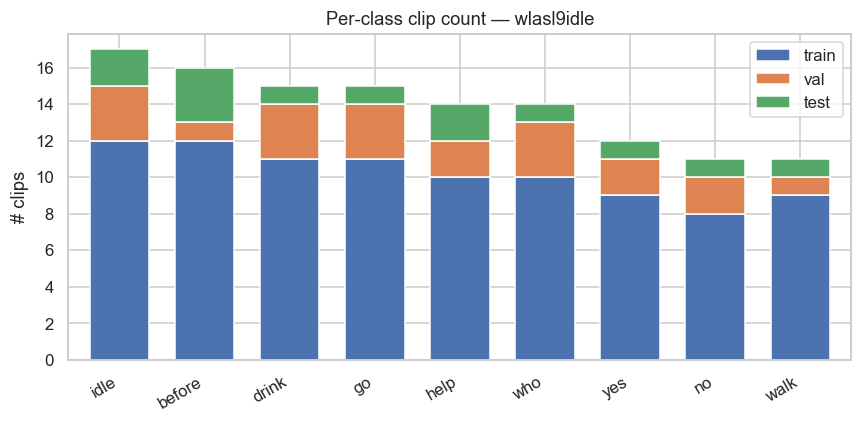

,train,val,test,total
idle,12,3,2,17
before,12,1,3,16
drink,11,3,1,15
go,11,3,1,15
help,10,2,2,14
who,10,3,1,14
yes,9,2,1,12
no,8,2,1,11
walk,9,1,1,11


In [3]:
# Per-class clip counts for the 9idle dataset (the comparison workhorse).
name = 'wlasl9idle'
classes = load_classes(name)
counts = {c: defaultdict(int) for c in classes}
for split in ('train', 'val', 'test'):
    for inst in load_split(name, split):
        # labels in manifest are ints; map back to gloss
        gloss = classes[inst['label']] if isinstance(inst.get('label'), int) else inst.get('gloss')
        counts[gloss][split] += 1

class_df = pd.DataFrame(counts).T[['train', 'val', 'test']].fillna(0).astype(int)
class_df['total'] = class_df.sum(axis=1)
class_df = class_df.sort_values('total', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
class_df[['train', 'val', 'test']].plot(kind='bar', stacked=True, ax=ax, width=0.7,
                                         color=['#4c72b0', '#dd8452', '#55a868'])
ax.set_title(f'Per-class clip count — {name}')
ax.set_ylabel('# clips'); ax.set_xlabel('')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.show()
class_df

## 2 · Model overview

Architecture and size, pulled from configs and checkpoint files.

In [4]:
import yaml

def ckpt_mb(p):
    return p.stat().st_size / 1024 / 1024 if p.exists() else float('nan')

rows = []
for m in MODELS:
    cfg = yaml.safe_load(m['config_path'].read_text())
    margs = cfg.get('model', {}).get('args', {})
    rows.append({
        'model': m['short'],
        'track': m['track'],
        'modality': m['modality'],
        'classes': margs.get('num_classes'),
        'arch': cfg['model']['name'],
        'epochs (cfg)': cfg.get('training', {}).get('epochs'),
        'batch': cfg.get('training', {}).get('batch_size'),
        'lr': cfg.get('training', {}).get('lr'),
        'ckpt MB': round(ckpt_mb(m['ckpt_path']), 1),
    })
model_table = pd.DataFrame(rows).set_index('model')
model_table

,track,modality,classes,arch,epochs (cfg),batch,lr,ckpt MB
model,,,,,,,,
T1·WLASL100,Track 1,Landmark,100,landmark_classifier,80,32,0.0003,3.6
T1·9idle,Track 1,Landmark,9,landmark_classifier,120,16,0.0003,3.5
T1·9idle-v2,Track 1,Landmark (pruned),9,landmark_classifier,120,16,0.0003,3.4
T2·video,Track 2,Video (ViT-S/16),8,temporal_tome_model,60,4,0.0010,123.5


## 3 · Training dynamics

Parsed from per-model training logs (no rerun needed).

In [5]:
EPOCH_RE = re.compile(
    r'\[train\] epoch (?P<epoch>\d+)/\d+ '
    r'loss=(?P<loss>[\d.]+) val_top1=(?P<v1>[\d.]+) val_top5=(?P<v5>[\d.]+) '
    r'\((?P<sec>\d+)s\)'
)
PARAM_RE = re.compile(r'params=([\d,]+)')

def parse_log(path: Path):
    if not path.exists():
        return pd.DataFrame(), None
    text = path.read_text()
    params = None
    pm = PARAM_RE.search(text)
    if pm: params = int(pm.group(1).replace(',', ''))
    records = [m.groupdict() for m in EPOCH_RE.finditer(text)]
    df = pd.DataFrame(records)
    if df.empty: return df, params
    for c in ('epoch', 'sec'): df[c] = df[c].astype(int)
    for c in ('loss', 'v1', 'v5'): df[c] = df[c].astype(float)
    return df, params

logs = {}
for m in MODELS:
    df, params = parse_log(m['log_path'])
    logs[m['short']] = df
    m['params'] = params
    m['epochs_run'] = int(df['epoch'].max()) if not df.empty else 0
    m['best_val_top1'] = float(df['v1'].max()) if not df.empty else float('nan')
    m['best_val_top5'] = float(df['v5'].max()) if not df.empty else float('nan')

summary = pd.DataFrame([
    {'model': m['short'],
     'params': m['params'],
     'epochs run': m['epochs_run'],
     'best val top-1': m['best_val_top1'],
     'best val top-5': m['best_val_top5']}
    for m in MODELS
]).set_index('model')
summary.style.format({'params': '{:,.0f}', 'best val top-1': '{:.3f}', 'best val top-5': '{:.3f}'})

,params,epochs run,best val top-1,best val top-5
model,,,,
T1·WLASL100,"315,236",80,0.287,0.609
T1·9idle,"303,497",120,0.650,0.950
T1·9idle-v2,"293,129",120,0.800,0.950
T2·video,"25,227,272",60,0.706,1.000


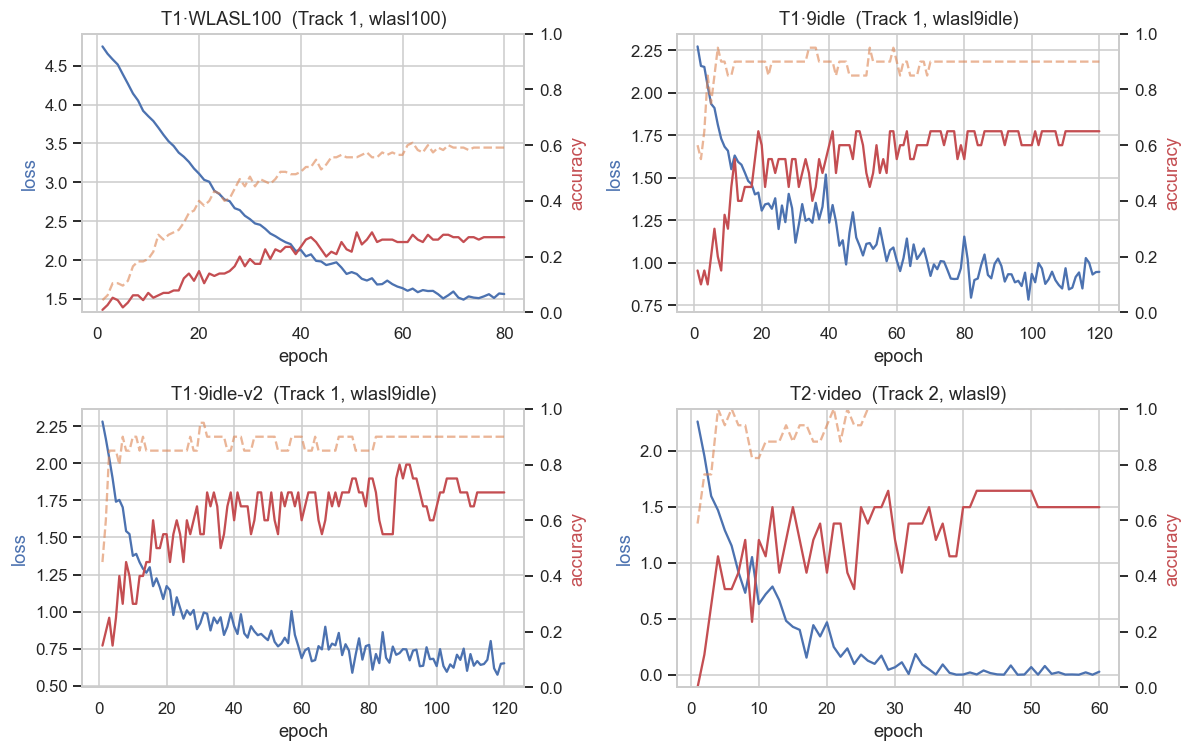

In [6]:
# Per-model training curves: loss + val top-1 over epochs.
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=False)
axes = axes.flatten()
for ax, m in zip(axes, MODELS):
    df = logs[m['short']]
    if df.empty:
        ax.set_title(f"{m['short']} — no log"); continue
    ax2 = ax.twinx()
    ax.plot(df['epoch'], df['loss'], color='#4c72b0', label='train loss')
    ax2.plot(df['epoch'], df['v1'], color='#c44e52', label='val top-1')
    ax2.plot(df['epoch'], df['v5'], color='#dd8452', alpha=0.6, ls='--', label='val top-5')
    ax.set_xlabel('epoch'); ax.set_ylabel('loss', color='#4c72b0')
    ax2.set_ylabel('accuracy', color='#c44e52'); ax2.set_ylim(0, 1)
    ax.set_title(f"{m['short']}  ({m['track']}, {m['dataset']})")
    ax2.grid(False)
fig.tight_layout(); plt.show()

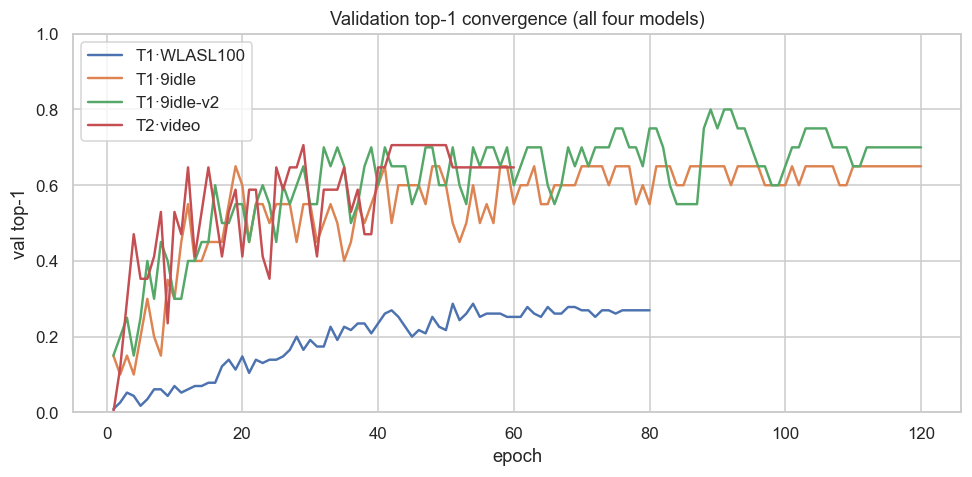

In [7]:
# Overlay val top-1 across all four models for direct comparison.
fig, ax = plt.subplots(figsize=(9, 4.5))
palette = sns.color_palette('deep', n_colors=len(MODELS))
for color, m in zip(palette, MODELS):
    df = logs[m['short']]
    if df.empty: continue
    ax.plot(df['epoch'], df['v1'], label=m['short'], color=color, linewidth=1.6)
ax.set_xlabel('epoch'); ax.set_ylabel('val top-1')
ax.set_ylim(0, 1); ax.set_title('Validation top-1 convergence (all four models)')
ax.legend(); plt.tight_layout(); plt.show()

## 4 · Test-set evaluation (held-out split)

Loads each `best.pt` and runs inference on the **test** split (`<dataset>_test.json`).

**Soft removal of `yes` and `before`**: these two classes had F1 = 0 on test (1 and 3 clips respectively — supports too small to be useful signal). We mask their logits at inference so the model can't predict them, and filter test samples whose true label is one of them. Training data + checkpoints stay untouched; this only changes how the test numbers are reported below. The 9-class T1 model becomes effectively a 7-class evaluation; the 8-class T2 model becomes a 6-class evaluation.

Per-model inference is wrapped in `try/except` so one failure doesn't break the rest.

In [8]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from utils import checkpoint as ckpt_utils
from utils.registry import build_dataset, build_model

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', DEVICE)

# Soft-removal: yes/before had F1=0 on the (very small) test split. We mask
# their logits at inference (so the model never predicts them) and filter test
# samples whose true label is one of them. Training data + checkpoints stay
# untouched — this only changes how we report eval numbers.
DROPPED_CLASSES = ['yes', 'before']

@torch.no_grad()
def evaluate_capture(model, loader, device, mask_indices=None):
    """Inference loop. Captures per-sample top-1/top-5 correctness and per-sample
    loss so we can post-filter samples cleanly (e.g. soft removal)."""
    model.eval()
    mask_idx_t = torch.tensor(mask_indices, device=device, dtype=torch.long) if mask_indices else None
    all_pred, all_label, all_top5_hit, all_loss = [], [], [], []
    for batch in loader:
        if len(batch) == 4:
            x, labels, _, _ = batch
            x = x.to(device); labels = labels.to(device)
            logits = model(x)
        else:
            lm, valid, labels, _, _ = batch
            lm = lm.to(device); valid = valid.to(device); labels = labels.to(device)
            try:    logits = model(lm, valid_mask=valid)
            except TypeError: logits = model(lm)
        if mask_idx_t is not None and mask_idx_t.numel() > 0:
            logits = logits.clone()
            logits[:, mask_idx_t] = float('-inf')
        per_sample_loss = F.cross_entropy(logits, labels, reduction='none')
        _, top5 = logits.topk(min(5, logits.size(-1)), dim=-1)
        top5_hit = (top5 == labels.unsqueeze(-1)).any(dim=-1)
        all_pred.append(top5[:, 0].cpu().numpy())
        all_label.append(labels.cpu().numpy())
        all_top5_hit.append(top5_hit.cpu().numpy())
        all_loss.append(per_sample_loss.cpu().numpy())
    preds  = np.concatenate(all_pred)     if all_pred     else np.array([], int)
    labels = np.concatenate(all_label)    if all_label    else np.array([], int)
    t5hit  = np.concatenate(all_top5_hit) if all_top5_hit else np.array([], bool)
    losses = np.concatenate(all_loss)     if all_loss     else np.array([], float)
    return {'preds': preds, 'labels': labels, 'top5_hit': t5hit, 'losses': losses, 'n': len(labels)}

_PATH_KEYS = ('manifest_path', 'videos_root', 'landmarks_root')

def build_eval_loader(cfg, split='test'):
    """Build a DataLoader over the chosen split, resolving relative paths."""
    ds_cfg = deepcopy(cfg['dataset'])
    args = dict(ds_cfg['val_args'])
    manifest = Path(args['manifest_path'])
    if split == 'test':
        args['manifest_path'] = str(manifest.with_name(manifest.name.replace('_val.json', '_test.json')))
    for key in _PATH_KEYS:
        if key in args and not Path(args[key]).is_absolute():
            args[key] = str(REPO_ROOT / args[key])
    ds = build_dataset(ds_cfg['name'], **args)
    bs = cfg.get('training', {}).get('batch_size', 16)
    return DataLoader(ds, batch_size=bs, shuffle=False, num_workers=0, pin_memory=False)

def summarize(captured, classes, dropped_names):
    """Filter samples whose true label is in `dropped_names`, then summarize."""
    dropped_idx = [i for i, c in enumerate(classes) if c in dropped_names]
    keep = ~np.isin(captured['labels'], dropped_idx) if dropped_idx else np.ones_like(captured['labels'], dtype=bool)
    preds  = captured['preds'][keep]
    labels = captured['labels'][keep]
    t5hit  = captured['top5_hit'][keep]
    losses = captured['losses'][keep]
    n = len(labels)
    return {
        'top1': float((preds == labels).mean()) if n else 0.0,
        'top5': float(t5hit.mean()) if n else 0.0,
        'loss': float(losses.mean()) if n else 0.0,
        'n': int(n),
        'preds': preds, 'labels': labels,
    }

def run_eval(m, split='test'):
    cfg = yaml.safe_load(m['config_path'].read_text())
    payload = ckpt_utils.load(m['ckpt_path'], map_location=DEVICE)
    train_cfg = payload.get('config', cfg)
    model = build_model(train_cfg['model']['name'], **train_cfg['model'].get('args', {}))
    model.load_state_dict(payload['model'])
    model = model.to(DEVICE)
    loader = build_eval_loader(cfg, split=split)
    classes = load_classes(m['dataset'])
    mask_indices = [i for i, c in enumerate(classes) if c in DROPPED_CLASSES]
    captured = evaluate_capture(model, loader, DEVICE, mask_indices=mask_indices)
    return summarize(captured, classes, DROPPED_CLASSES), train_cfg

device: mps


In [9]:
# Heavy cell: runs all four models on their test splits.
results = {}
for m in MODELS:
    print(f"[eval] {m['short']} ...", end=' ', flush=True)
    try:
        res, _ = run_eval(m, split='test')
        results[m['short']] = res
        print(f"top1={res['top1']:.3f} top5={res['top5']:.3f} n={res['n']}")
    except Exception as e:
        print(f"FAILED: {type(e).__name__}: {e}")
        results[m['short']] = None

[eval] T1·WLASL100 ... 

/Users/jadantoun/Desktop/final-ml/ml-final/.venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


top1=0.263 top5=0.605 n=76
[eval] T1·9idle ... 

top1=0.444 top5=1.000 n=9
[eval] T1·9idle-v2 ... 

top1=0.778 top5=1.000 n=9
[eval] T2·video ... 

/Users/jadantoun/Desktop/final-ml/ml-final/.venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


top1=0.429 top5=1.000 n=7


In [10]:
rows = []
for m in MODELS:
    r = results.get(m['short'])
    rows.append({
        'model': m['short'],
        'dataset': m['dataset'],
        'test top-1': r['top1'] if r else float('nan'),
        'test top-5': r['top5'] if r else float('nan'),
        'test loss':  r['loss'] if r else float('nan'),
        '# test samples': r['n']    if r else 0,
        'best val top-1': m['best_val_top1'],
    })
test_table = pd.DataFrame(rows).set_index('model')
test_table.style.format({
    'test top-1': '{:.3f}', 'test top-5': '{:.3f}', 'test loss': '{:.3f}',
    'best val top-1': '{:.3f}',
})

,dataset,test top-1,test top-5,test loss,# test samples,best val top-1
model,,,,,,
T1·WLASL100,wlasl100,0.263,0.605,3.005,76,0.287
T1·9idle,wlasl9idle,0.444,1.000,1.134,9,0.650
T1·9idle-v2,wlasl9idle,0.778,1.000,0.605,9,0.800
T2·video,wlasl9,0.429,1.000,1.488,7,0.706


## 7 · Track 1 v1 vs v2 — does pruning to 48 keypoints help?

Identical dataset (`wlasl9idle`), identical architecture; v2 drops 27 low-value keypoints (head + hip).
Compares val curves and final test-set metrics. Test numbers below carry the soft removal of `yes`/`before` from Section 4.

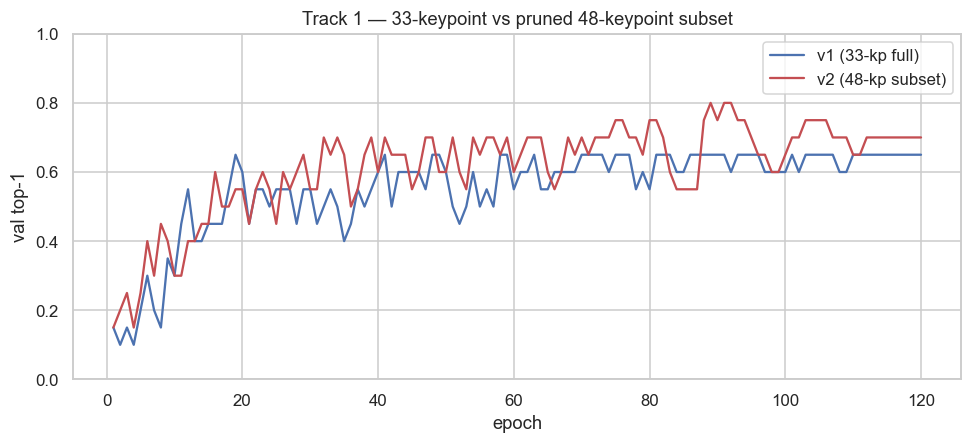

,best val top-1,epochs,test top-1,test top-5
variant,,,,
v1 (33-kp full),0.650,120,0.444,1.000
v2 (48-kp subset),0.800,120,0.778,1.000


In [13]:
v1, v2 = logs['T1·9idle'], logs['T1·9idle-v2']
fig, ax = plt.subplots(figsize=(9, 4.2))
if not v1.empty: ax.plot(v1['epoch'], v1['v1'], label='v1 (33-kp full)', color='#4c72b0')
if not v2.empty: ax.plot(v2['epoch'], v2['v1'], label='v2 (48-kp subset)', color='#c44e52')
ax.set_ylim(0, 1); ax.set_xlabel('epoch'); ax.set_ylabel('val top-1')
ax.set_title('Track 1 — 33-keypoint vs pruned 48-keypoint subset')
ax.legend(); plt.tight_layout(); plt.show()

cmp = pd.DataFrame([
    {'variant': 'v1 (33-kp full)', 'best val top-1': v1['v1'].max() if not v1.empty else None,
     'epochs': int(v1['epoch'].max()) if not v1.empty else None},
    {'variant': 'v2 (48-kp subset)', 'best val top-1': v2['v1'].max() if not v2.empty else None,
     'epochs': int(v2['epoch'].max()) if not v2.empty else None},
]).set_index('variant')
for short, lab in [('T1·9idle', 'v1 (33-kp full)'), ('T1·9idle-v2', 'v2 (48-kp subset)')]:
    if results.get(short) is not None:
        cmp.loc[lab, 'test top-1'] = results[short]['top1']
        cmp.loc[lab, 'test top-5'] = results[short]['top5']
cmp.style.format({'best val top-1': '{:.3f}', 'test top-1': '{:.3f}', 'test top-5': '{:.3f}'})

## 8 · Track 1 vs Track 2 — landmark vs video on the shared sign classes

Track 1 (9idle) and Track 2 (wlasl9) share 6 sign classes after dropping `yes`/`before`: `drink, go, help, who, no, walk`.
Track 1's predictions are restricted to those 6 (idle, yes, before all excluded) and compared against Track 2's same 6 classes.

In [14]:
SHARED = ['drink', 'go', 'help', 'who', 'no', 'walk']  # yes/before removed

def restrict_to_shared(preds, labels, classes_orig):
    """Drop samples whose true label is not in SHARED; re-map both arrays to shared label space."""
    name_to_orig = {n: i for i, n in enumerate(classes_orig)}
    shared_idx = [name_to_orig[n] for n in SHARED if n in name_to_orig]
    keep_set = set(shared_idx)
    mask = np.isin(labels, list(keep_set))
    p, l = preds[mask], labels[mask]
    remap = {orig: SHARED.index(classes_orig[orig]) for orig in shared_idx}
    p_r = np.array([remap.get(int(x), -1) for x in p])
    l_r = np.array([remap[int(x)] for x in l])
    return p_r, l_r

rows = []
for short, ds in [('T1·9idle', 'wlasl9idle'), ('T1·9idle-v2', 'wlasl9idle'), ('T2·video', 'wlasl9')]:
    r = results.get(short)
    if r is None: continue
    cls = load_classes(ds)
    p, l = restrict_to_shared(r['preds'], r['labels'], cls)
    if len(l) == 0: continue
    top1 = float((p == l).mean())
    rows.append({'model': short, 'n (shared)': int(len(l)),
                 'top-1 (6-class restricted)': top1})
shared_df = pd.DataFrame(rows).set_index('model')
shared_df.style.format({'top-1 (6-class restricted)': '{:.3f}'})

,n (shared),top-1 (6-class restricted)
model,,
T1·9idle,7,0.286
T1·9idle-v2,7,0.714
T2·video,7,0.429


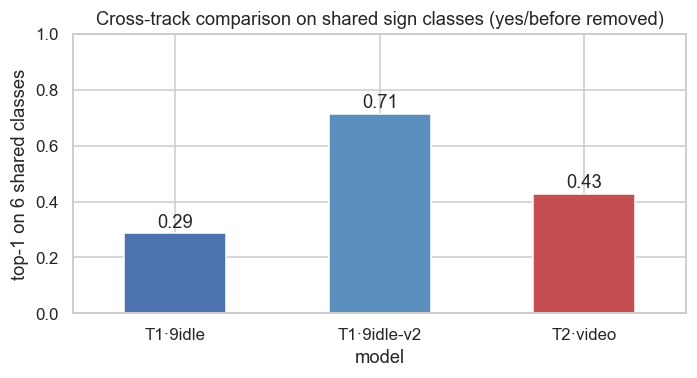

In [15]:
# Bar chart for the cross-track comparison.
if not shared_df.empty:
    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    shared_df['top-1 (6-class restricted)'].plot(kind='bar', ax=ax, color=['#4c72b0', '#5a8fbe', '#c44e52'])
    ax.set_ylim(0, 1); ax.set_ylabel('top-1 on 6 shared classes')
    ax.set_title('Cross-track comparison on shared sign classes (yes/before removed)')
    for i, v in enumerate(shared_df['top-1 (6-class restricted)']):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center')
    plt.xticks(rotation=0); plt.tight_layout(); plt.show()

---

### Notes for the report

- **Tables to lift directly**: `ds_table` (dataset stats), `model_table` (architecture summary), `summary` (training-time best val), `test_table` (test numbers with yes/before soft-removed), `cmp` (v1 vs v2 ablation), `shared_df` (cross-track).
- **Figures**: training-curve grid, val-top-1 overlay, v1-vs-v2 curve, cross-track bar.
- **Soft removal of yes/before**: classes had F1 = 0 on test (1 and 3 clips). At eval time we mask their logits and drop test samples whose true label is one of them. Training data + checkpoints are untouched.
- **Caveats**:
  - Test sets are still small after the soft removal (`wlasl100` = 76, `wlasl9` = 8, `wlasl9idle` = 9).
  - Track 2 effectively becomes 6 signs; the cross-track comparison drops both `idle` (T1 only) and `yes`/`before` (everywhere) to keep the comparison apples-to-apples.